In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

import pandas as pd

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

import cv2

from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import sys
import os


In [5]:
# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"Running in Google Colab: {IN_COLAB}")

Running in Google Colab: True


In [6]:
repo_path = 'cv22928'

if IN_COLAB:
    # Only clone the repo if the directory doesn't exist
    if not os.path.exists(repo_path):
        print(f"Cloning {repo_path} repository...")
        !git clone https://github.com/egozi/cv22928.git
    else:
        print(f"Repository {repo_path} already exists. Skipping clone.")

    # Append the object_detection module path
    sys.path.append(os.path.join('/content', repo_path, 'object_detection'))
else:
    sys.path.append('../object_detection')  # adjust path as needed
    sys.path.append('../dataset')  # adjust path as needed
    sys.path.append('../tools')  # adjust path as needed
    sys.path.append('../loss')  # adjust path as needed
    sys.path.append('../models')  # adjust path as needed

Cloning cv22928 repository...
Cloning into 'cv22928'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 90 (delta 44), reused 56 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 18.71 MiB | 24.95 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [7]:
from vis import visualize_detection_results, create_detection_summary_plot, plot_yolo_results, draw_im

from datasets import ClassificationDataset

ImportError: cannot import name 'ClassificationDataset' from 'datasets' (/usr/local/lib/python3.11/dist-packages/datasets/__init__.py)

In [8]:

# Download latest version
data_path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

print("Path to dataset files:", data_path)

100%|██████████| 1.65G/1.65G [00:41<00:00, 42.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1


In [9]:
PATH = Path(data_path)
IMAGE_ROOT = PATH / 'voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/'

paths = list(PATH.iterdir())
paths


[PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/PASCAL_VOC'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctest_06-nov-2007'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctrainval_06-nov-2007'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtest_06-Nov-2007')]

In [10]:
list((PATH / 'pascal_voc'/ 'PASCAL_VOC').iterdir())

[PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_val2007.json'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_train2007.json'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_val2012.json'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_train2012.json'),
 PosixPath('/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_test2007.json')]

In [11]:
# Load the training annotations
train_json = json.load((PATH/'pascal_voc/PASCAL_VOC/pascal_train2007.json').open())
train_json.keys()

dict_keys(['images', 'type', 'annotations', 'categories'])

In [12]:
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
train_json[IMAGES][:5]

[{'file_name': '000012.jpg', 'height': 333, 'width': 500, 'id': 12},
 {'file_name': '000017.jpg', 'height': 364, 'width': 480, 'id': 17},
 {'file_name': '000023.jpg', 'height': 500, 'width': 334, 'id': 23},
 {'file_name': '000026.jpg', 'height': 333, 'width': 500, 'id': 26},
 {'file_name': '000032.jpg', 'height': 281, 'width': 500, 'id': 32}]

In [13]:
train_json[ANNOTATIONS][:5]

[{'segmentation': [[155, 96, 155, 270, 351, 270, 351, 96]],
  'area': 34104,
  'iscrowd': 0,
  'image_id': 12,
  'bbox': [155, 96, 196, 174],
  'category_id': 7,
  'id': 1,
  'ignore': 0},
 {'segmentation': [[184, 61, 184, 199, 279, 199, 279, 61]],
  'area': 13110,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [184, 61, 95, 138],
  'category_id': 15,
  'id': 2,
  'ignore': 0},
 {'segmentation': [[89, 77, 89, 336, 403, 336, 403, 77]],
  'area': 81326,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [89, 77, 314, 259],
  'category_id': 13,
  'id': 3,
  'ignore': 0},
 {'segmentation': [[8, 229, 8, 500, 245, 500, 245, 229]],
  'area': 64227,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [8, 229, 237, 271],
  'category_id': 2,
  'id': 4,
  'ignore': 0},
 {'segmentation': [[229, 219, 229, 500, 334, 500, 334, 219]],
  'area': 29505,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [229, 219, 105, 281],
  'category_id': 2,
  'id': 5,
  'ignore': 0}]

In [14]:
train_json[CATEGORIES][:5]

[{'supercategory': 'none', 'id': 1, 'name': 'aeroplane'},
 {'supercategory': 'none', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'none', 'id': 3, 'name': 'bird'},
 {'supercategory': 'none', 'id': 4, 'name': 'boat'},
 {'supercategory': 'none', 'id': 5, 'name': 'bottle'}]

In [15]:
# Load the annotation and image info
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
images = {im['id']: im for im in train_json[IMAGES]}
categories = {cat['id']: cat['name'] for cat in train_json[CATEGORIES]}

# Build DataFrame rows
voc_rows = []
for ann in train_json[ANNOTATIONS]:
    image_id = ann['image_id']
    image_info = images[image_id]
    category_id = ann['category_id']
    label_name = categories[category_id]
    # VOC bbox: [x, y, width, height]
    x, y, w, h = ann['bbox']
    row = {
        'ImageID': image_info['file_name'].replace('.jpg', ''),  # match bus-truck style
        'LabelName': label_name,
        'XMin': x / image_info['width'],
        'XMax': (x + w) / image_info['width'],
        'YMin': y / image_info['height'],
        'YMax': (y + h) / image_info['height'],
    }
    voc_rows.append(row)

VOC_DF = pd.DataFrame(voc_rows)
display(VOC_DF.head())

,ImageID,LabelName,XMin,XMax,YMin,YMax
0,000012,car,0.310000,0.702000,0.288288,0.810811
1,000017,person,0.383333,0.581250,0.167582,0.546703
2,000017,horse,0.185417,0.839583,0.211538,0.923077
3,000023,bicycle,0.023952,0.733533,0.458000,1.000000
4,000023,bicycle,0.685629,1.000000,0.438000,1.000000


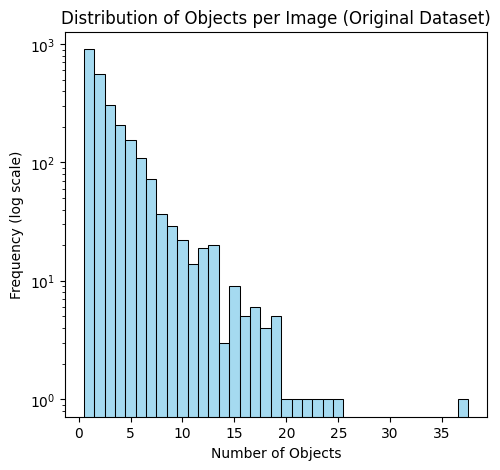

In [16]:
# Count objects per image for the original dataset
original_object_counts = VOC_DF['ImageID'].value_counts()

# Define bins for the original dataset (0-5, 6-10, etc.)
max_original_objects = original_object_counts.max()
original_bins = np.arange(0, max_original_objects + 5, 5)

# Plot histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(original_object_counts, bins=original_bins, kde=False, color='skyblue', discrete=True)
plt.title('Distribution of Objects per Image (Original Dataset)')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')

In [17]:
# create a custom dataset
class OpenImages(Dataset):
    def __init__(self, df, image_folder = IMAGE_ROOT):
        self.df = df
        self.unique_images = df['ImageID'].unique()
        self.root = image_folder

    def __len__(self):
        return len(self.unique_images)

    def __getitem__(self, index):
        image_id = self.unique_images[index]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)  # converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        df = self.df.copy()
        df = df[df['ImageID'] == image_id]  # getting the row based on the index
        h, w, _ = image.shape
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes*np.array([w,h,w,h])).astype(np.uint16)
        classes = df['LabelName'].values.tolist()

        return image, boxes, classes, image_path

In [18]:
ds = OpenImages(VOC_DF)
len(ds)

2501

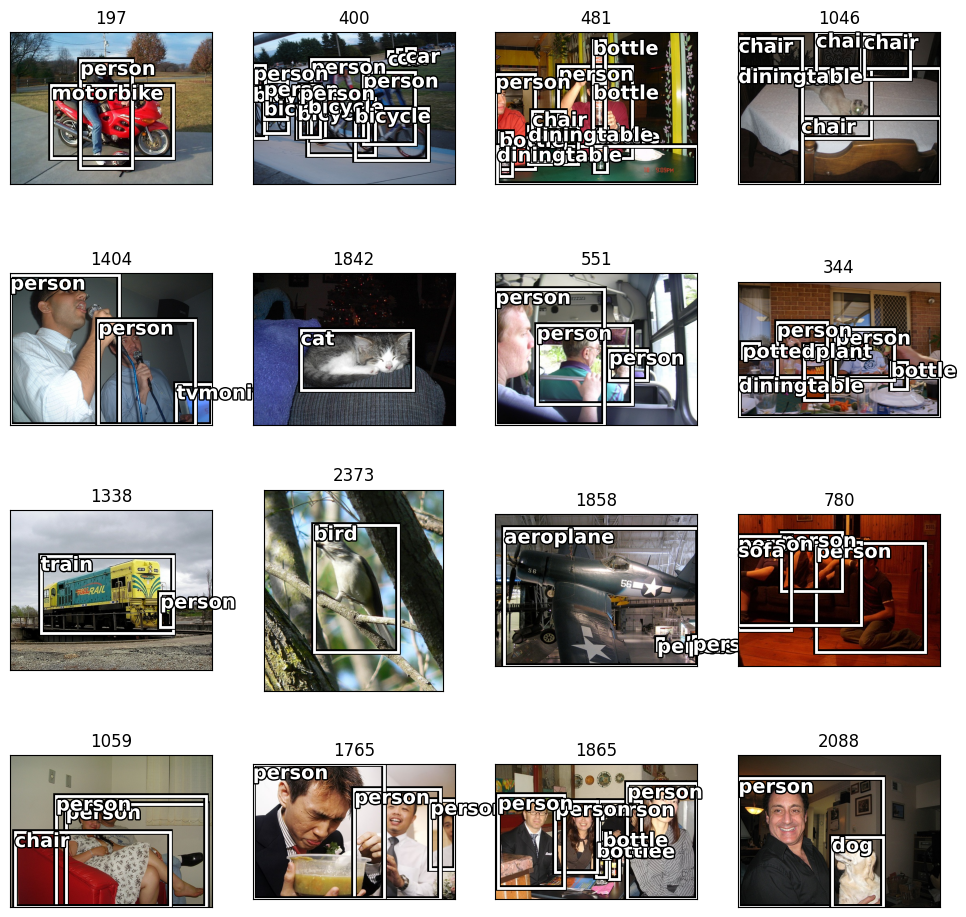

In [19]:
# Randomly select 16 indices
random_indices = np.random.choice(len(ds), 16, replace=False)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the random indices and display the images
for i, idx in enumerate(random_indices):
    im, bbs, clss, _ = ds[idx]
    draw_im(im, bbs=bbs, classes=clss, ax=axes[i], figsize=(3,3), title=idx)

# only the largest object

In [20]:
# For each image, keep only the largest bounding box and add a column for relative object size
def get_largest_object_df(df, images_dict):
    rows = []
    for image_id, group in df.groupby('ImageID'):
        # Find the largest bbox by area (in pixels)
        max_area = -1
        max_row = None
        for idx, row in group.iterrows():
            img_info = images_dict.get(row['ImageID'] + '.jpg') or images_dict.get(row['ImageID'])
            if img_info is None:
                continue
            w_img, h_img = img_info['width'], img_info['height']
            xmin, xmax = row['XMin'], row['XMax']
            ymin, ymax = row['YMin'], row['YMax']
            # Convert normalized to pixel coordinates
            x1, x2 = xmin * w_img, xmax * w_img
            y1, y2 = ymin * h_img, ymax * h_img
            area = (x2 - x1) * (y2 - y1)
            if area > max_area:
                max_area = area
                max_row = row.copy()
                max_row['object_pixel_area'] = area
                max_row['image_pixel_area'] = w_img * h_img
                max_row['relative_object_size'] = area / (w_img * h_img)
        if max_row is not None:
            rows.append(max_row)
    largest_obj_df = pd.DataFrame(rows)
    return largest_obj_df

largest_object_df = get_largest_object_df(VOC_DF, {im['file_name']: im for im in train_json['images']})
display(largest_object_df.head())

larges_bb_ds = OpenImages(largest_object_df)
print(len(larges_bb_ds))

,ImageID,LabelName,XMin,XMax,YMin,YMax,object_pixel_area,image_pixel_area,relative_object_size
0,000012,car,0.310000,0.702000,0.288288,0.810811,34104.0,166500,0.204829
2,000017,horse,0.185417,0.839583,0.211538,0.923077,81326.0,174720,0.465465
7,000023,person,0.005988,0.727545,0.002000,0.924000,111101.0,167000,0.665275
9,000026,car,0.178000,0.674000,0.372372,0.636637,21824.0,166500,0.131075
10,000032,aeroplane,0.206000,0.750000,0.274021,0.651246,28832.0,140500,0.205210


2501


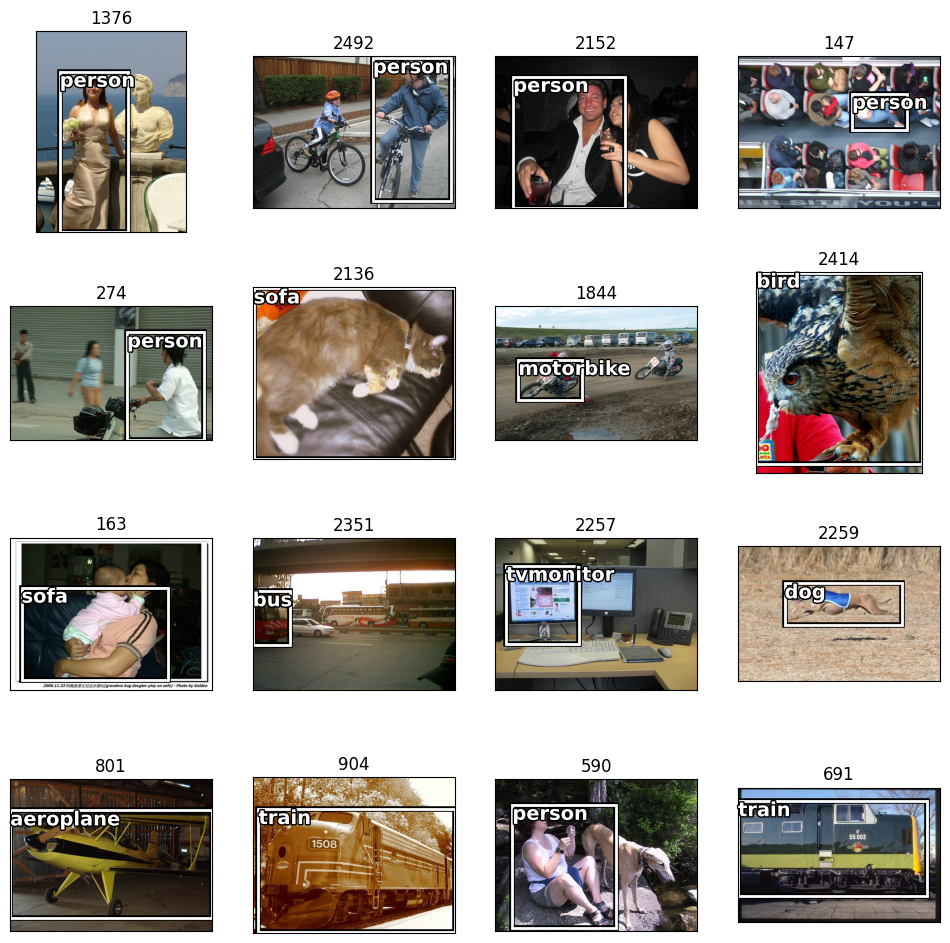

In [22]:
# Randomly select 16 indices
random_indices = np.random.choice(len(larges_bb_ds), 16, replace=False)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the random indices and display the images
for i, idx in enumerate(random_indices):
    im, bbs, clss, _ = larges_bb_ds[idx]
    draw_im(im, bbs=bbs, classes=clss, ax=axes[i], figsize=(3,3), title=idx)

# train a classifier for biggest object label

In [ ]:
# Example transforms for ResNet
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = ClassificationDataset(largest_object_df, IMAGE_ROOT, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)


In [ ]:
# Split the dataset into train and validation
train_df, val_df = train_test_split(largest_object_df, test_size=0.2, stratify=largest_object_df['LabelName'], random_state=42)

# Prepare datasets and dataloaders
train_dataset = ClassificationDataset(train_df, IMAGE_ROOT, transform=transform)
val_dataset = ClassificationDataset(val_df, IMAGE_ROOT, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(largest_object_df['LabelName'].unique())
model = models.resnet34(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 5
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

# Save the model
torch.save(model.state_dict(), "resnet34_largest_object.pth")

/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1 [Val]: 100%|██████████| 16/16 [00:17<00:00,  1.10s/it]


Epoch 1/5 - Train Loss: 1.3514 - Train Acc: 0.6145 | Val Loss: 0.7394 - Val Acc: 0.7904


Epoch 2 [Val]: 100%|██████████| 16/16 [00:16<00:00,  1.03s/it]


Epoch 2/5 - Train Loss: 0.3330 - Train Acc: 0.9235 | Val Loss: 0.6858 - Val Acc: 0.7984


Epoch 3 [Val]: 100%|██████████| 16/16 [00:16<00:00,  1.01s/it]


Epoch 3/5 - Train Loss: 0.0879 - Train Acc: 0.9910 | Val Loss: 0.7090 - Val Acc: 0.8004


Epoch 4 [Val]: 100%|██████████| 16/16 [00:16<00:00,  1.02s/it]


Epoch 4/5 - Train Loss: 0.0306 - Train Acc: 0.9995 | Val Loss: 0.6819 - Val Acc: 0.8004


Epoch 5 [Val]: 100%|██████████| 16/16 [00:15<00:00,  1.04it/s]

Epoch 5/5 - Train Loss: 0.0162 - Train Acc: 0.9990 | Val Loss: 0.7039 - Val Acc: 0.8104


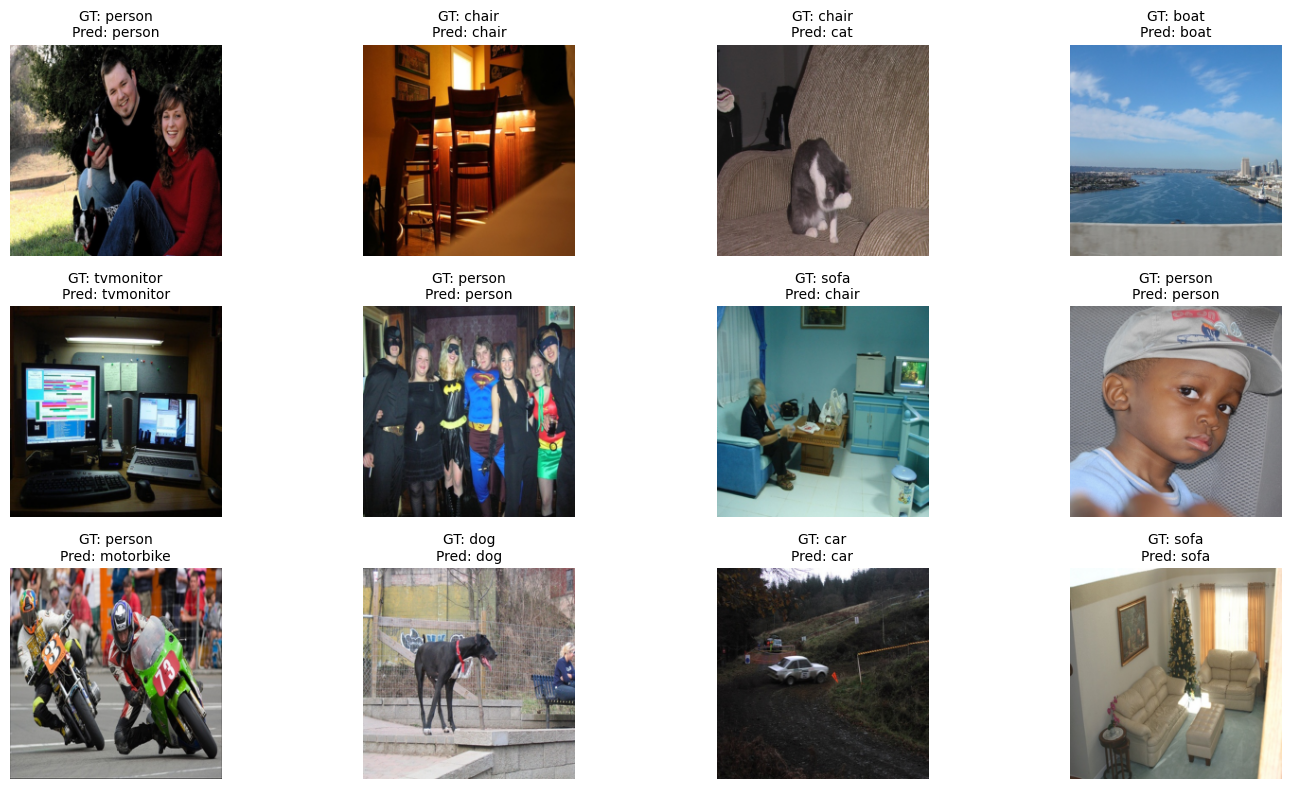

In [ ]:
import matplotlib.pyplot as plt

# Set model to eval mode and move to device
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get a batch from the validation set
images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)
with torch.no_grad():
    outputs = model(images)
    _, preds = outputs.max(1)

# Map indices to label names
idx2label = {i: l for i, l in enumerate(sorted(largest_object_df['LabelName'].unique()))}
true_labels = [idx2label[int(l)] for l in labels.cpu()]
pred_labels = [idx2label[int(p)] for p in preds.cpu()]

# Plot a grid of images with true and predicted labels
n_show = min(12, images.size(0))
plt.figure(figsize=(15, 8))
for i in range(n_show):
    plt.subplot(3, 4, i+1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # unnormalize
    img = img.clip(0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"GT: {true_labels[i]}\nPred: {pred_labels[i]}", fontsize=10)

plt.tight_layout()


# classify bounding box only

In [23]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, df, image_dir, classes, transforms=None):
        self.df = df
        self.image_dir = image_dir
        self.transforms = transforms
        self.classes = classes
        self.image_ids = df['ImageID'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df['ImageID'] == image_id]

        # Read image
        image_path = f"{self.image_dir}/{image_id}.jpg"
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width, _ = image.shape

        # Get bboxes and labels
        boxes = []
        labels = []
        for _, row in records.iterrows():
            xmin = row['XMin'] * width
            xmax = row['XMax'] * width
            ymin = row['YMin'] * height
            ymax = row['YMax'] * height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.classes.index(row['LabelName']))

        # Albumentations format
        transformed = self.transforms(image=image, bboxes=boxes, class_labels=labels)
        # transformed = self.transforms(image=image, bboxes=boxes, class_labels=labels)
        image = transformed['image']
        boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
        labels = torch.tensor(transformed['class_labels'], dtype=torch.long)

        return image, boxes, labels


In [24]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Affine(
            translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},  # shift_limit=0.05
            scale=(0.9, 1.1),  # scale_limit=0.1 means ±10%, so 0.9 to 1.1
            rotate=(-15, 15),  # rotate_limit=15
            p=0.5
        ),
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

def get_val_transforms():
    return A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

In [25]:
def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images)
    return images, list(boxes), list(labels)

In [26]:
class_names = sorted(largest_object_df['LabelName'].unique().tolist())

# Split the dataset
train_df, val_df = train_test_split(largest_object_df, test_size=0.2, random_state=42)

train_dataset = ObjectDetectionDataset(train_df, IMAGE_ROOT, classes=class_names, transforms=get_train_transforms())
val_dataset = ObjectDetectionDataset(val_df, IMAGE_ROOT, classes=class_names, transforms=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


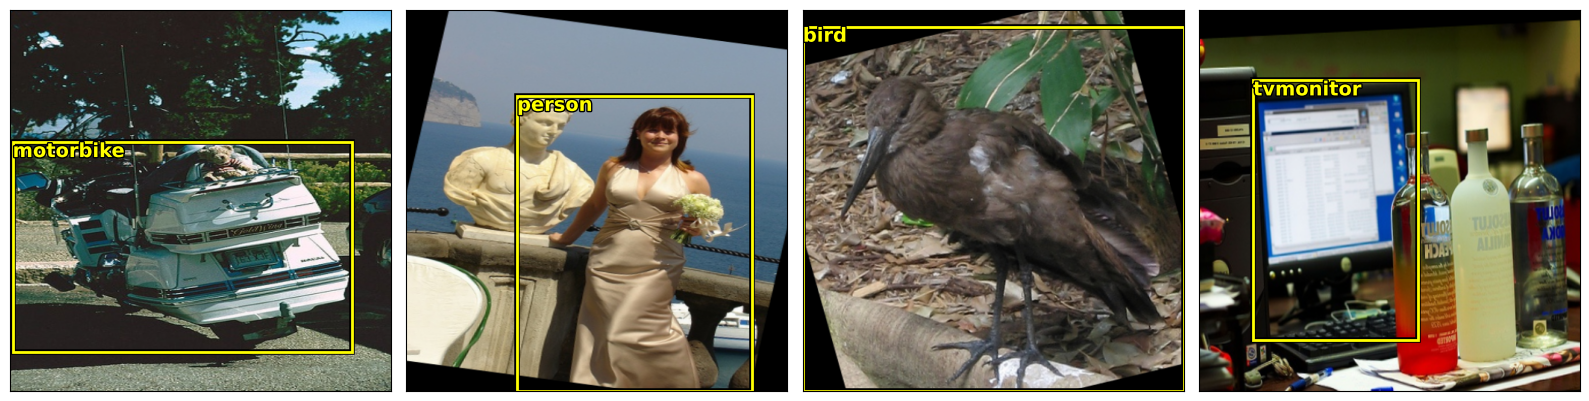

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import torchvision.transforms.functional as F


def denormalize(image, mean, std):
    image = image.clone().permute(1, 2, 0)  # [C,H,W] → [H,W,C]
    image = image * torch.tensor(std) + torch.tensor(mean)
    return image.clamp(0, 1)

mean = [0.485, 0.456, 0.406]  # change if you use different stats
std = [0.229, 0.224, 0.225]

def show_batch(images, boxes, labels, n=4, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        img = denormalize(images[i], mean, std).numpy()

        # Handle the actual data structure
        img_boxes = boxes[i].cpu().numpy() if len(boxes[i]) > 0 else np.array([]).reshape(0, 4)
        img_labels = labels[i].cpu().numpy() if len(labels[i]) > 0 else np.array([])

        # Convert label indices to class names
        cls = [class_names[int(c)] for c in img_labels] if len(img_labels) > 0 else []

        draw_im(img, img_boxes, cls, ax=ax, color='yellow')
    plt.tight_layout()
    plt.show()

# Get a batch from the train_loader
images, boxes, labels = next(iter(train_loader))  # shapes: images [B,3,H,W], boxes [B,4], labels [B]

# Show the batch
show_batch(images, boxes, labels, n=min(4, len(images)))



In [46]:
# Model: ResNet34 with regression head
class ResNet34BBox(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet34(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 4)  # 4 for [XMin, YMin, XMax, YMax]

    def forward(self, x):
        return self.backbone(x)

# Loss flag: 'l1' or 'l2'
loss_type = 'l1'  # Change to 'l2' for MSELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet34BBox(pretrained=True).to(device)
criterion = nn.L1Loss() if loss_type == 'l1' else nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Training and validation loop
epochs = 10
for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    for images, bboxes, _ in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = images.to(device)
        # bboxes = bboxes.to(device)

        # Convert list of tensors to a single tensor (take first bbox from each image)
        bboxes_tensor = torch.stack([bbox[0] if len(bbox) > 0 else torch.zeros(4) for bbox in bboxes])
        bboxes_tensor = bboxes_tensor.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, bboxes_tensor)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes, _ in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = images.to(device)

            # Convert list of tensors to a single tensor (take first bbox from each image)
            bboxes_tensor = torch.stack([bbox[0] if len(bbox) > 0 else torch.zeros(4) for bbox in bboxes])
            bboxes_tensor = bboxes_tensor.to(device)
            # bboxes = bboxes.to(device)

            outputs = model(images)
            loss = criterion(outputs, bboxes_tensor)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

# Save the model
torch.save(model.state_dict(), "resnet34_bbox_regression.pth")

Epoch 1 [Val]: 100%|██████████| 32/32 [00:06<00:00,  4.65it/s]


Epoch 1/10 - Train Loss: 104.71485 | Val Loss: 78.74591


Epoch 2 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.05it/s]


Epoch 2/10 - Train Loss: 77.15586 | Val Loss: 77.90223


Epoch 3 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.46it/s]


...

Epoch 8/10 - Train Loss: 75.51291 | Val Loss: 75.44811


Epoch 9 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.12it/s]


Epoch 9/10 - Train Loss: 73.88630 | Val Loss: 79.93416


Epoch 10 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.47it/s]


Epoch 10/10 - Train Loss: 74.78398 | Val Loss: 80.03211


<Figure size 1600x800 with 0 Axes>

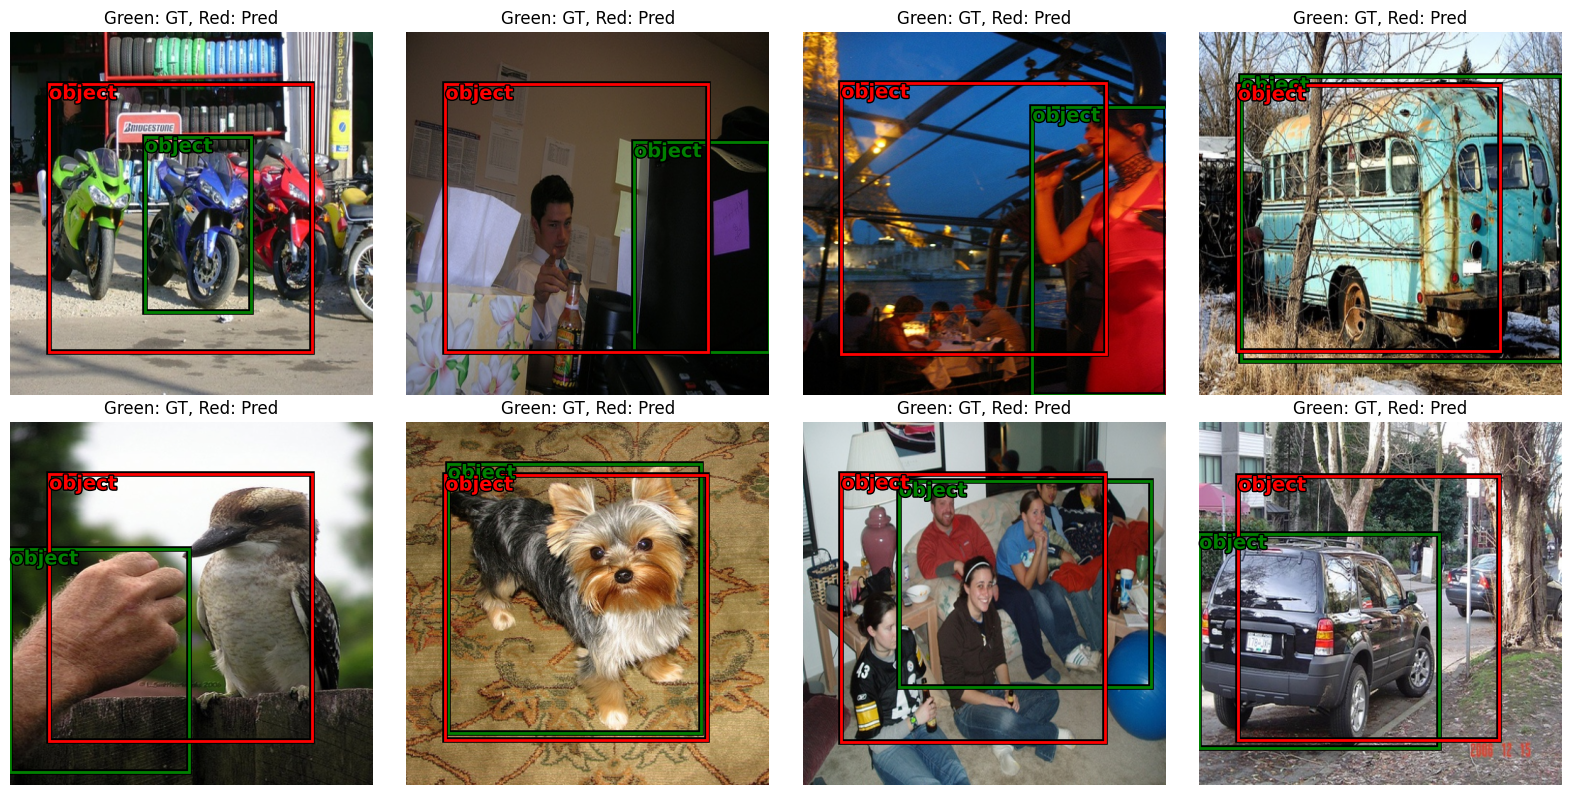

In [47]:
# Demonstrate bounding box regression results on validation set

import matplotlib.pyplot as plt

model.eval()
images, bboxes, _ = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    preds = model(images).cpu().numpy()
images = images.cpu().permute(0, 2, 3, 1).numpy()
# bboxes = [bb.cpu().numpy() for bb in bboxes] #bboxes.cpu().numpy()

n_show = min(8, images.shape[0])
plt.figure(figsize=(16, 8))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
ax = axes.flatten()
for i in range(n_show):
    plt.subplot(2, 4, i+1)
    img = images[i]
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # unnormalize
    img = img.clip(0, 1)
    h, w = img.shape[:2]
    # True bbox (green)
    # x1, y1, x2, y2 = bboxes[i]
    img_boxes = bboxes[i][0].cpu().numpy() # Get the first bbox from the list for this image
    draw_im(img, [img_boxes], ['gt'], ax=ax[i], color='green')

    draw_im(img, [preds[i]], ['pred'], ax=ax[i], color='red')

    plt.axis('off')
    plt.title("Green: GT, Red: Pred")

plt.tight_layout()